Original 2D Training Shape: (466, 10)
Reshaped 3D CNN Training Shape: (466, 10, 1)

Training 1D CNN Model...



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Final Test Loss: 0.4824
Final Test Accuracy: 0.7436


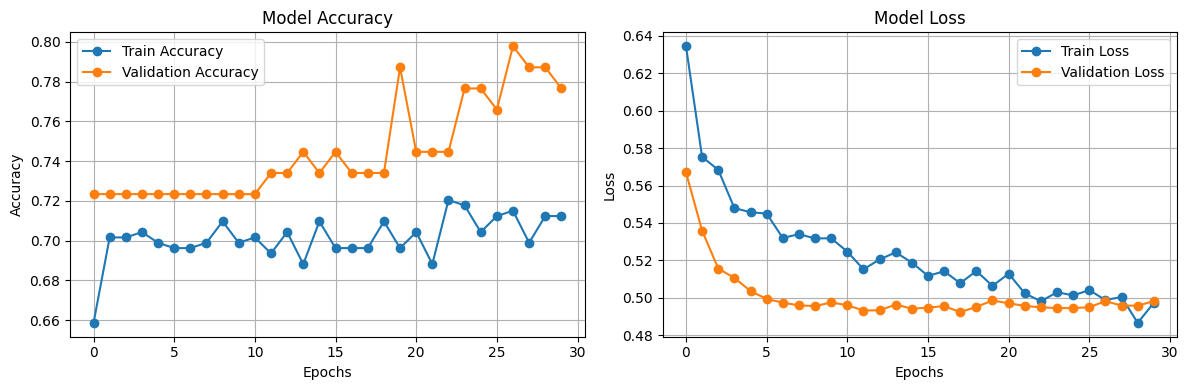

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

# ==========================================
# 1. Load and Preprocess Dataset
# ==========================================
df = pd.read_csv("/content/sample_data/Indian Liver Patient Dataset (ILPD).csv")

# Preprocessing
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df = df.fillna(df.mean())

X = df.drop('Selector', axis=1)
y = df['Selector'].apply(lambda x: 1 if x == 1 else 0)

# ==========================================
# 2. Data Splitting and Scaling
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reshape data for Conv1D: (samples, timesteps/features, channels)
X_train_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

print(f"Original 2D Training Shape: {X_train_scaled.shape}")
print(f"Reshaped 3D CNN Training Shape: {X_train_cnn.shape}\n")

# ==========================================
# 3. Build Conv1D Model
# ==========================================
model = Sequential([
    Conv1D(filters=16, kernel_size=2, activation='relu', input_shape=(X_train_cnn.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(32, activation='relu'),
    Dropout(0.2), # Dropout to prevent overfitting
    Dense(1, activation='sigmoid') # Binary output
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# ==========================================
# 4. Train Model
# ==========================================
print("Training 1D CNN Model...\n")
history = model.fit(X_train_cnn, y_train, epochs=30, batch_size=16, validation_split=0.2, verbose=0)

# ==========================================
# 5. Evaluate and Visualize
# ==========================================
test_loss, test_acc = model.evaluate(X_test_cnn, y_test, verbose=0)
print(f"\nFinal Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_acc:.4f}")

# Plotting Accuracy and Loss Curves
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()